# Week 4 Day 4 Lab


### Problem 1
1. Pick a dataset you have not used yet from our collection of datasets: [click here for link](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets).
2. Load the dataset into your notebook
3. Plot a feature of the dataset against another feature.
4. Does there seem to be a relationship?

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


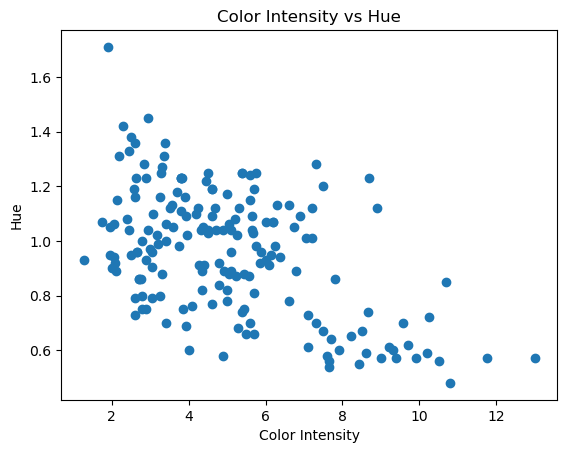

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

wine = pd.read_csv("wine.csv")
display(wine.head()) #checking the data

# plotting the two features of color intensity and hue from the wine data
plt.scatter(wine["Color intensity"], wine["Hue"])
plt.xlabel("Color Intensity")
plt.ylabel("Hue")
plt.title("Color Intensity vs Hue")
plt.show()

# It looks like there is maybe a negative relationship.
# As color intensity gets bigger, hue seems to go down a little.
# the points are pretty spread out, but definetly forms a downward relationship.

### Problem 2
1. Compute the correlation between all the features.
2. What is the largest correlated/anti-correlated features?
3. Do you have an explanation for why?

In [15]:
#only using number columns because correlation needs numerical values as discussed in class
num_wine = wine.select_dtypes("number")
corr = num_wine.corr()
corr 
# Can get rid of or ignore the diagonals because each column is correlated with itself just gives a 1.
# Some of the largest features are that the strongest relationship is the one with the correlation farthest from 0
#and positive means they move together, and negative means one goes up while the other goes down.

#From the data, the total phenols and Flavanoids have one of the strongest positive correlations.
# Their correlation is about 0.864, so they will tend to increase together, so as total phenols goes up, flavanoids usually go up too.
# I didn't know what either of these are, but when I looked them up, both are chemical measurements from the wine so correlation makes sense.

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Class,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic acid,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity of ash,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid phenols,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


### Problem 3
Create one dataset with a strong positive correlation and another with a strong negative correlation. Plot them side by side and compare their correlation coefficients.

positive correlation: 0.9871259281372902
negative correlation: -0.9879639562148003


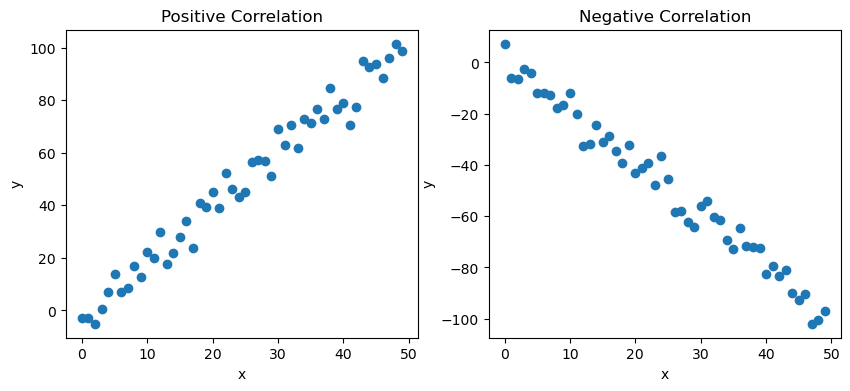

In [6]:
x =np.arange(0,50)

#for a strong positive correlation, do a y goes up when x goes up
y_positive = 2*x + np.random.normal(0,5,50)
#negative correlation would be something like y goes down when x goes up
y_negative = -2*x + np.random.normal(0,5,50)

positive_corr = np.corrcoef(x, y_positive)[0,1]
negative_corr = np.corrcoef(x, y_negative)[0,1]
print("positive correlation:",positive_corr)
print("negative correlation:",negative_corr)

#Now plotting both examples for positive and negative correlations side by side

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(x, y_positive)
axes[0].set_title("Positive Correlation")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].scatter(x, y_negative)
axes[1].set_title("Negative Correlation")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.show()

# The first plot has the positive correlation because y increases as x increases generally, positive slope.
# The second plot has a negative correlation because y decreases as x increases, so a negative slope
# The positive correlation is closer to 1, and the negative correlation should be close to -1.